In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Student_Performance.csv')
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes':1,'No':0})
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype(int)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


<Axes: >

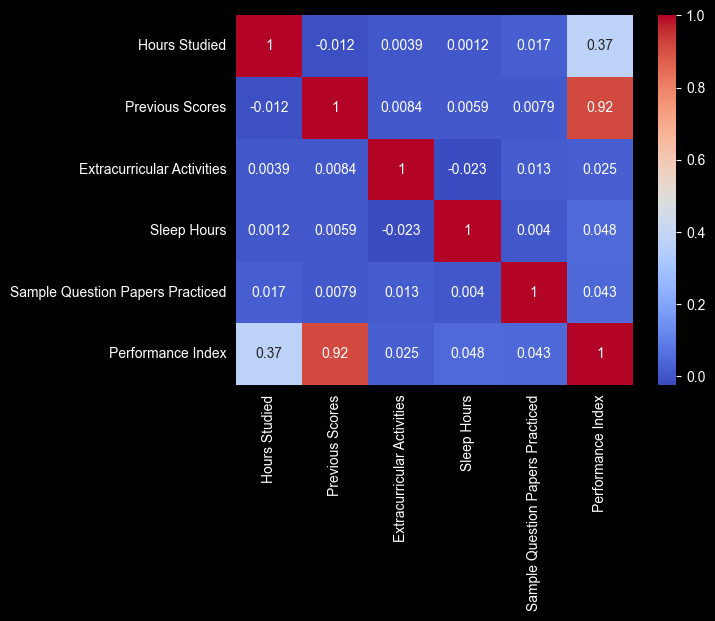

In [3]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [4]:
X_train = df[['Hours Studied', 'Previous Scores']].values
y_train = df['Performance Index'].values

print(X_train.shape, y_train.shape)

(10000, 2) (10000,)


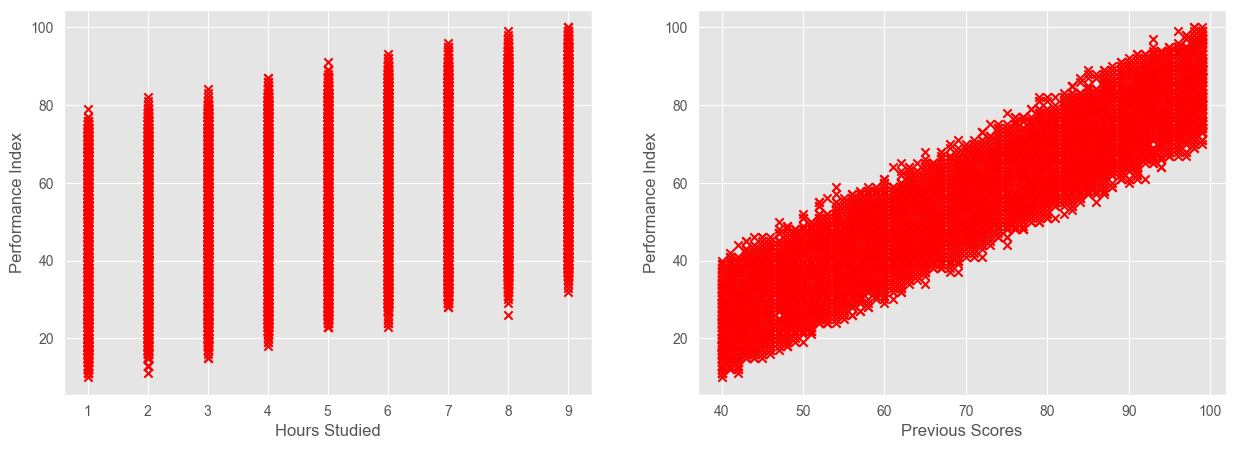

In [5]:
plt.style.use('ggplot')

fig, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].scatter(X_train[:,0], y_train, marker='x', c='red')
axs[0].set_xlabel('Hours Studied')
axs[0].set_ylabel('Performance Index')

axs[1].scatter(X_train[:,1], y_train, marker='x', c='red')
axs[1].set_xlabel('Previous Scores')
axs[1].set_ylabel('Performance Index')

plt.show()

In [6]:
def predict(X,W,b):
    return np.dot(X,W) + b
x_train = X_train[0,:]
w = np.array([0.5, 0.5])
b = 0
print(x_train)
print(predict(x_train, w, b))
print("Loss: ", (predict(x_train, w, b) - y_train[0]) ** 2)

[ 7 99]
53.0
Loss:  1444.0


In [7]:
def compute_model_output(X, W, b):
    m = X.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = np.dot(X[i],W) + b
    return f_wb

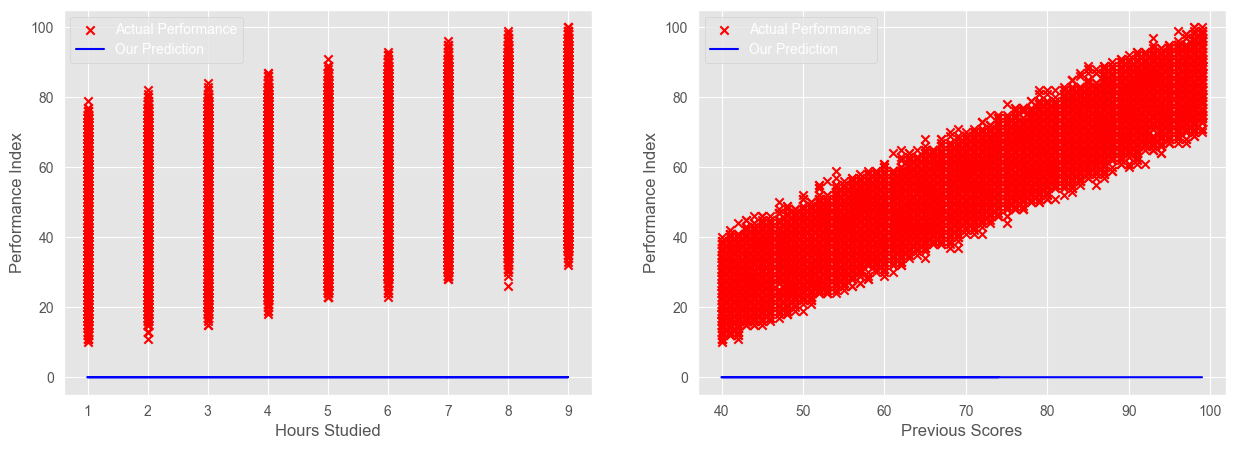

In [30]:
W = np.zeros(X_train.shape[1]).astype(int)
b = 0
tmp_f_wb = compute_model_output(X_train, W, b)

fig, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].scatter(X_train[:,0], y_train, marker='x', c='red', label='Actual Performance')
axs[0].plot(X_train[:,0], tmp_f_wb, c='b',label='Our Prediction')
axs[0].legend()
axs[0].set_xlabel('Hours Studied')
axs[0].set_ylabel('Performance Index')

axs[1].scatter(X_train[:,1], y_train, marker='x', c='red', label = 'Actual Performance')
axs[1].plot(X_train[:,1], tmp_f_wb, c='b',label='Our Prediction')
axs[1].legend()
axs[1].set_xlabel('Previous Scores')
axs[1].set_ylabel('Performance Index')
plt.show()

In [31]:
def compute_cost(X, y, W, b):
    m = X.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = np.dot(X[i],W) + b
        cost = (f_wb- y[i]) ** 2
        cost_sum = cost_sum + cost

    total_cost = (1 / (2 * m)) * cost_sum
    return total_cost


In [32]:
def compute_gradient(X, y, W, b):
    m, n = X.shape
    dj_dW = np.zeros(n).astype(int)
    dj_db = 0

    for i in range(m):
        f_wb_i = np.dot(X[i], W) + b
        err_i = f_wb_i - y[i]

        dj_db += err_i

        for j in range(n):
            dj_dW[j] += err_i * X[i, j]

    dj_dW = dj_dW / m
    dj_db = dj_db / m

    return dj_dW, dj_db

In [33]:
def gradient_descent(X, y, alpha, iterations):
    W = np.zeros(X.shape[1]).astype(int)
    b = 0
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        W = W - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            print(f"Iteration: {i+1}, Cost: {compute_cost(X, y, w, b)}")
    print(f"w: {W}, b: {b}")
    return W, b

In [34]:
learning_rate = 0.01
iterations = 1000

W, b = gradient_descent(X_train, y_train, learning_rate, iterations)
tmp_f_wb = compute_model_output(X_train, W, b)


Iteration: 1, Cost: 219.95597959901306
Iteration: 101, Cost: 82.36852054675234
Iteration: 201, Cost: 63.93459751839742
Iteration: 301, Cost: 61.464826504702145
Iteration: 401, Cost: 61.13392738731393
Iteration: 501, Cost: 61.089593631155
Iteration: 601, Cost: 61.08365380891911
Iteration: 701, Cost: 61.08285799346789
Iteration: 801, Cost: 61.0827513703715
Iteration: 901, Cost: 61.082737085044826
w: [ 240.070125 2793.314276], b: 18.00472268010474


In [35]:
print(W,b)
print(tmp_f_wb)
print(predict(X_train[0,:], W, b))


[ 240.070125 2793.314276] 18.00472268010474
[278236.60892168 230030.05585468 144397.59379868 ... 233303.51038068
 273130.12061968 208403.75202168]
278236.60892168054


Text(0, 0.5, 'Performance Index')

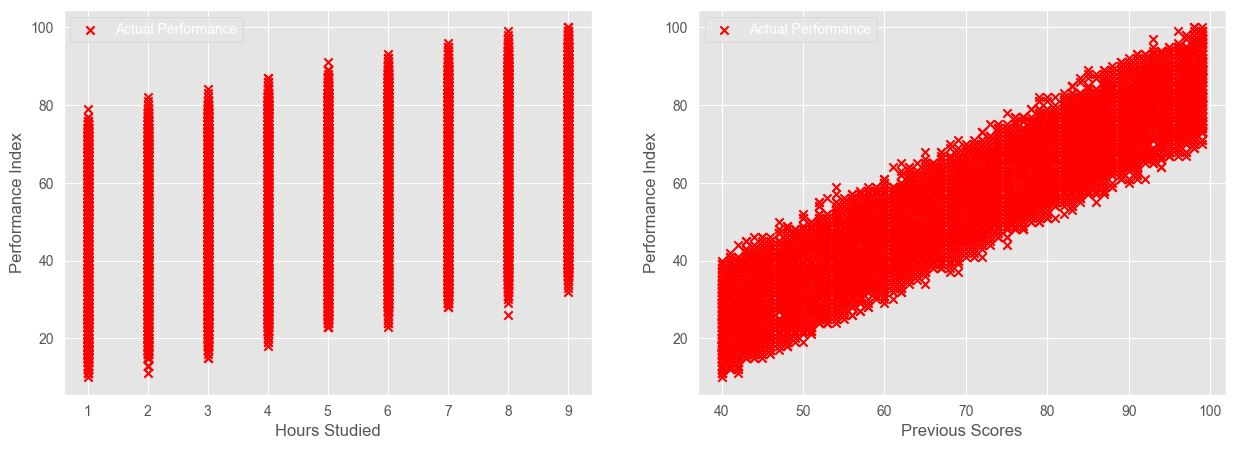

In [36]:
fig, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].scatter(X_train[:,0], y_train, marker='x', c='red', label='Actual Performance')
# axs[0].plot(X_train[:,0], tmp_f_wb, c='b',label='Our Prediction')
axs[0].legend()
axs[0].set_xlabel('Hours Studied')
axs[0].set_ylabel('Performance Index')

axs[1].scatter(X_train[:,1], y_train, marker='x', c='red', label = 'Actual Performance')
# axs[1].plot(X_train[:,1], tmp_f_wb, c='b',label='Our Prediction')
axs[1].legend()
axs[1].set_xlabel('Previous Scores')
axs[1].set_ylabel('Performance Index')